In [4]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [12]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
valid_loader = DataLoader(valid_dataset, batch_size=64)

(11610, 8) (5160, 8) (3870, 8)


In [6]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [14]:
import time

def train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	warmup_scheduler=None, 
	scheduler=None, 
	patience=None,
	checkpoint_path='best_model.pt',
	clip_grad=False
	):
	history = {
		'train_losses' : [],
		'train_metrics' : [],
		'valid_metrics' : [],
	}
	best_epoch = 0
	best_valid_metric = float('-inf') if metric.higher_is_better else float('inf')
	patience_counter = 0
	
	for epoch in range(n_epochs):
		if warmup_scheduler is not None:
			warmup_scheduler.step()

		#--------------------------------------------
		#                  Training
		#--------------------------------------------
		losses = []
		metric.reset()
		model.train()
		t0 = time.time()

		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			losses.append(loss.item())
			loss.backward()
			if clip_grad:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		train_loss = np.mean(losses)
		train_metric = metric.compute().item()

		#--------------------------------------------
		#                 Evaluation
		#--------------------------------------------
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		valid_metric = metric.compute().item()

		#---------------------------------------------
		#                 Checkpoint
		#---------------------------------------------
		is_best = (valid_metric > best_valid_metric) if metric.higher_is_better else (valid_metric < best_valid_metric)

		if is_best:
			torch.save(model.state_dict(), checkpoint_path)
			best_valid_metric = valid_metric
			best_epoch = epoch + 1
			print(f"\tCheckpoint, valid metric: {best_valid_metric:.3f}")

		#---------------------------------------------
		#                 Scheduling
		#---------------------------------------------
		if scheduler is not None:
			if epoch >= warmup_scheduler.total_iters if warmup_scheduler is not None else 0:
				if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
					scheduler.step(valid_metric)
				else:
					scheduler.step()

		#---------------------------------------------
		#                 Logging
		#---------------------------------------------
		history['train_losses'].append(train_loss)
		history['train_metrics'].append(train_metric)
		history['valid_metrics'].append(valid_metric)
		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Train Loss: {round(train_loss,3)}, '
			+f'Train Metric: {round(train_metric,3)}, ' 
			+f'Valid Metric: {round(valid_metric,3)}, '
			+f'Learning Rate: {optimizer.param_groups[0]["lr"]:.3f}, ' if scheduler is not None else ''
			# +f'Best Valid Metric: {best_valid_metric:.3f}, '
			+f'Time: {round(time.time()-t0,2)}s'
		)

		#---------------------------------------------
		#                 Early Stopping
		#---------------------------------------------
		if patience is not None:
			if is_best:
				patience_counter = 0
			else:
				patience_counter += 1
				if patience_counter >= patience:
					print(f"Early stopping, best valid metric: {best_valid_metric:.3f}, epoch: {best_epoch}")
					break

		# if epoch>=2:
		# 	break
	print(f"Restoring best model from epoch {best_epoch} with valid metric: {best_valid_metric:.3f}")
	model.load_state_dict(torch.load(checkpoint_path))

	return history

def plot_history(history, metric):
	n_epochs = len(history['train_metrics'])
	plt.plot(np.arange(n_epochs) + 1, history['train_metrics'], linestyle='--', color='r', marker='.', label='Train')
	plt.plot(np.arange(n_epochs) + 1, history['valid_metrics'], linestyle='--', color='b', marker='.', label='Valid')
	plt.legend()
	plt.grid()
	plt.xlabel('Epochs')
	plt.ylabel(f'{metric.__class__.__name__}')
	plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_3612\1722673048.py:28: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warmup_scheduler.step()


	Checkpoint, valid metric: 0.571
Epoch: 1/100, Train Loss: 0.732, Train Metric: 0.627, Valid Metric: 0.571, Learning Rate: 0.019, 
	Checkpoint, valid metric: 0.501
Epoch: 2/100, Train Loss: 0.525, Train Metric: 0.53, Valid Metric: 0.501, Learning Rate: 0.028, 
Epoch: 3/100, Train Loss: 0.487, Train Metric: 0.505, Valid Metric: 0.564, Learning Rate: 0.037, 
	Checkpoint, valid metric: 0.486
Epoch: 4/100, Train Loss: 0.481, Train Metric: 0.504, Valid Metric: 0.486, Learning Rate: 0.046, 
Epoch: 5/100, Train Loss: 0.435, Train Metric: 0.478, Valid Metric: 0.489, Learning Rate: 0.055, 
	Checkpoint, valid metric: 0.462
Epoch: 6/100, Train Loss: 0.436, Train Metric: 0.48, Valid Metric: 0.462, Learning Rate: 0.064, 
Epoch: 7/100, Train Loss: 0.455, Train Metric: 0.489, Valid Metric: 0.462, Learning Rate: 0.073, 
Epoch: 8/100, Train Loss: 0.446, Train Metric: 0.483, Valid Metric: 0.542, Learning Rate: 0.082, 
Epoch: 9/100, Train Loss: 0.43, Train Metric: 0.476, Valid Metric: 0.464, Learning Rat

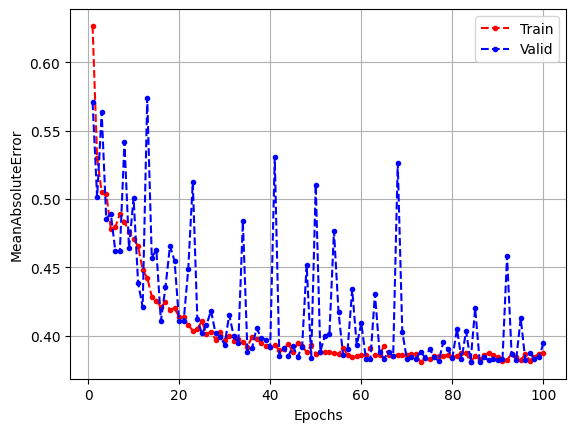

In [15]:
# model = nn.Sequential(
# 	nn.BatchNorm1d(8),
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.LeakyReLU(),
# 	nn.BatchNorm1d(30),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.LeakyReLU(),
# 	nn.BatchNorm1d(50),
# 	nn.Linear(in_features=50, out_features=1),
# ).to(device)

class PriceRegressor(nn.Module):
	def __init__(self, n_features, n_hidden1=30, n_hidden2=50):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=n_hidden1, bias=False), 
			nn.BatchNorm1d(n_hidden1),
			nn.LeakyReLU(),
			nn.Linear(in_features=n_hidden1, out_features=n_hidden2, bias=False), 
			nn.BatchNorm1d(n_hidden2),
			nn.LeakyReLU(),
			nn.Linear(in_features=n_hidden2, out_features=1),
		)
        
	def forward(self, X):
		y = self.sequential(X)
		return y
model = PriceRegressor(8).to(device)


def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        # nn.init.zeros_(module.bias) # comment if bias=False in Linear layers
model.apply(use_he_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=10)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=100, 
	warmup_scheduler=warmup_scheduler, 
	scheduler=scheduler, 
	patience=20,
	checkpoint_path='best_model.pt',
	clip_grad=False
    )
plot_history(history, metric)

In [16]:
model.eval()
metric.reset()
# with torch.no_grad():
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred = model(X_batch)
		metric.update(y_pred, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.382


In [17]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_features": 8,
        "n_hidden1": 30,
        "n_hidden2": 50,
    }
}
torch.save(model_data, "fashion_mnist_model.pt")

loaded_data = torch.load("fashion_mnist_model.pt", weights_only=True)
new_model = PriceRegressor(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model

PriceRegressor(
  (sequential): Sequential(
    (0): Linear(in_features=8, out_features=30, bias=False)
    (1): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=30, out_features=50, bias=False)
    (4): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=50, out_features=1, bias=True)
  )
)